Loading file: 04-RTSOCS - 2022.10.13-10.03.20.csv
File loaded successfully!
Shape: (5524, 21)
Columns found: ['insole', 'foot', 'timestamp', 'seq', 'acx', 'acy', 'acz', 'gyrx', 'gyry', 'gyrz', 'p_toe_1_f', 'p_toe_1_b', 'p_toe_3', 'p_toe_5', 'p_arc_i', 'p_arc_o', 'p_heel_i', 'p_heel_o', 'roll', 'pitch', 'yaw']
Estimated sampling frequency: 98749.3 Hz


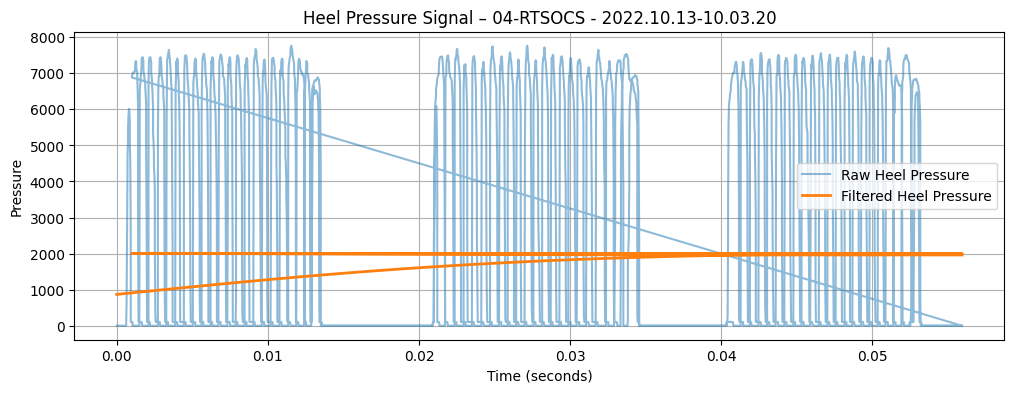


Heel Strikes Detected: 1
Cadence (steps/min): nan
Stride time variability (s): nan


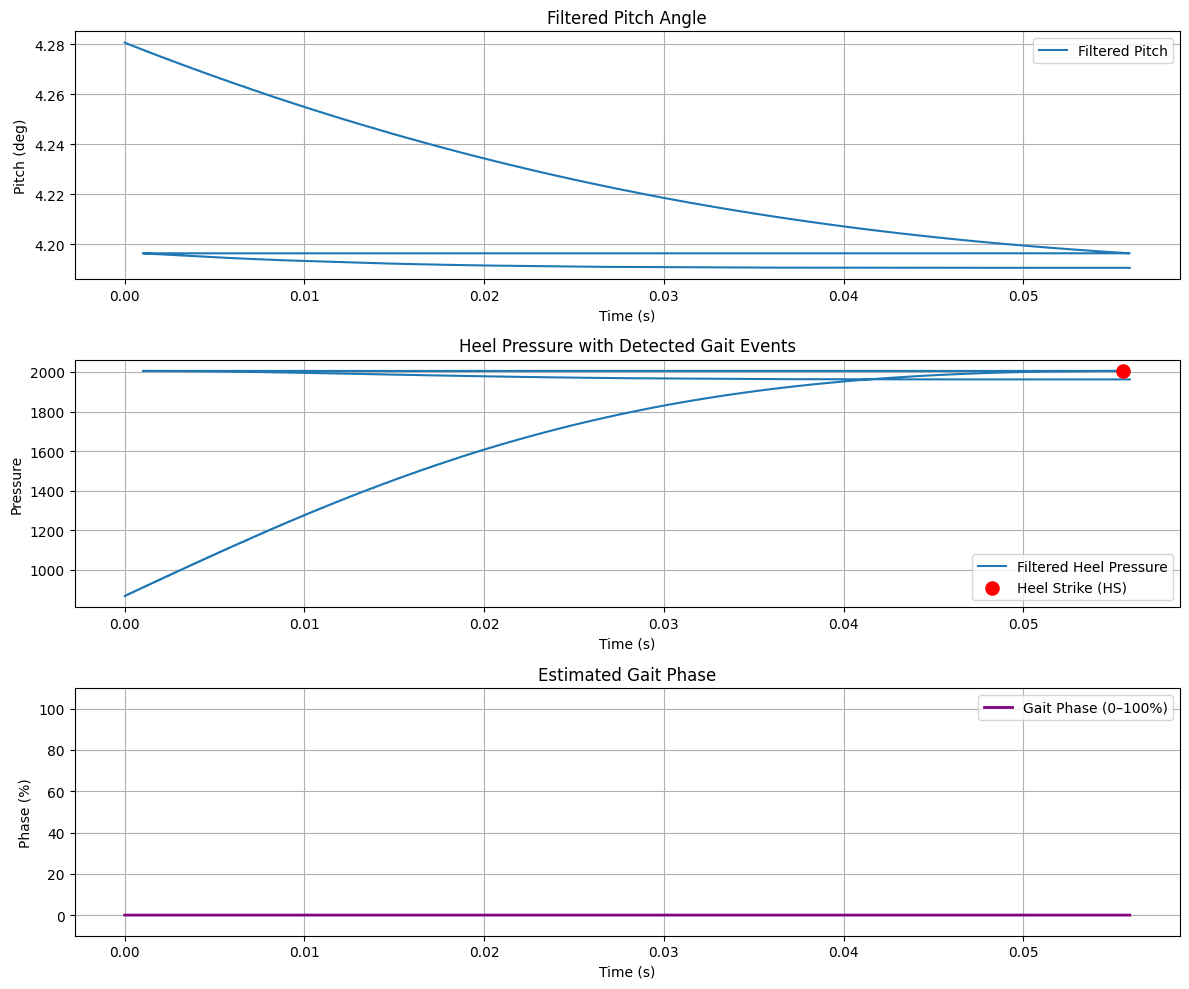

In [5]:
# =============================================================================
# Gait Phase Estimation from Insole IMU + Pressure Data
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ────────────────────────────────────────────────
# STEP 1: Load your CSV file
# ────────────────────────────────────────────────
# This is your new file name (update only if you change the file)
CSV_FILENAME = "04-RTSOCS - 2022.10.13-10.03.20.csv"

print(f"Loading file: {CSV_FILENAME}")

try:
    # In Colab: make sure you uploaded the file first via the Files sidebar
    data = pd.read_csv(CSV_FILENAME)
    print("File loaded successfully!")
    print("Shape:", data.shape)
    print("Columns found:", list(data.columns))
except FileNotFoundError:
    print(f"ERROR: File '{CSV_FILENAME}' not found in the current folder.")
    print("Instructions for Google Colab:")
    print("1. Left sidebar → Files icon")
    print("2. Click 'Upload to session storage'")
    print("3. Select your file: 04-RTSOCS - 2022.10.13-10.03.20.csv")
    print("4. Wait until upload finishes, then run this cell again")
    raise
except Exception as e:
    print("Error while reading the file:", str(e))
    raise

# ────────────────────────────────────────────────
# STEP 2: Extract signals
# ────────────────────────────────────────────────
required_cols = ["timestamp", "pitch", "p_heel_i", "p_heel_o"]
missing = [col for col in required_cols if col not in data.columns]

if missing:
    print("ERROR: These required columns are missing:", missing)
    print("Your CSV must contain at least: timestamp, pitch, p_heel_i, p_heel_o")
    raise ValueError("Missing required columns")

time = data["timestamp"].values.astype(float)
pitch = data["pitch"].values.astype(float)
heel_pressure = data["p_heel_i"].values.astype(float) + data["p_heel_o"].values.astype(float)

# Convert timestamp to relative seconds
time = (time - time[0]) / 1000.0

# ────────────────────────────────────────────────
# Low-pass filter function
# ────────────────────────────────────────────────
def butter_lowpass(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# Estimate sampling rate
try:
    fs = 1.0 / np.mean(np.diff(time))
    print(f"Estimated sampling frequency: {fs:.1f} Hz")
except:
    fs = 100.0  # fallback – adjust if you know the real rate
    print("Warning: Could not compute fs reliably → using fallback 100 Hz")

pitch_filtered = butter_lowpass(pitch, cutoff=6,   fs=fs)
heel_filtered  = butter_lowpass(heel_pressure, cutoff=25, fs=fs)

# ────────────────────────────────────────────────
# Plot heel pressure (raw vs filtered)
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(time, heel_pressure, label='Raw Heel Pressure', alpha=0.5)
plt.plot(time, heel_filtered, label='Filtered Heel Pressure', linewidth=2)
plt.title("Heel Pressure Signal – 04-RTSOCS - 2022.10.13-10.03.20")
plt.xlabel("Time (seconds)")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True)
plt.show()

# ────────────────────────────────────────────────
# Heel Strike (HS) detection
# ────────────────────────────────────────────────
threshold = 0.20 * np.max(heel_filtered)   # you can try 0.15–0.30 if needed
peaks, _ = find_peaks(
    heel_filtered,
    distance=fs * 0.5,                     # min ~0.5 s between steps
    height=threshold,
    prominence=0.1 * np.std(heel_filtered)
)
peaks = peaks.astype(int)

print(f"\nHeel Strikes Detected: {len(peaks)}")

# ────────────────────────────────────────────────
# Toe-Off (TO) detection – min between consecutive HS
# ────────────────────────────────────────────────
toe_offs = []
if len(peaks) > 1:
    for i in range(len(peaks)-1):
        segment = heel_filtered[peaks[i]:peaks[i+1]]
        if len(segment) > 3:  # avoid tiny segments
            to_idx = np.argmin(segment) + peaks[i]
            toe_offs.append(to_idx)
toe_offs = np.array(toe_offs, dtype=int)

# ────────────────────────────────────────────────
# Gait Phase (0–100%)
# ────────────────────────────────────────────────
phase = np.zeros_like(time)
if len(peaks) > 1:
    for i in range(len(peaks)-1):
        start = peaks[i]
        end   = peaks[i+1]
        if end > start:
            phase[start:end] = np.linspace(0, 100, end - start)

# ────────────────────────────────────────────────
# Basic gait metrics
# ────────────────────────────────────────────────
if len(peaks) > 1:
    stride_times = np.diff(time[peaks])
    mean_stride = np.mean(stride_times)
    cadence = 60.0 / mean_stride if mean_stride > 0 else np.nan
    stride_variability = np.std(stride_times) if len(stride_times) > 1 else np.nan
else:
    cadence = np.nan
    stride_variability = np.nan

print(f"Cadence (steps/min): {cadence:.1f}")
print(f"Stride time variability (s): {stride_variability:.3f}")

# ────────────────────────────────────────────────
# Final plots
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 10))

# 1. Filtered Pitch
plt.subplot(3, 1, 1)
plt.plot(time, pitch_filtered, label="Filtered Pitch")
plt.title("Filtered Pitch Angle")
plt.xlabel("Time (s)")
plt.ylabel("Pitch (deg)")
plt.grid(True)
plt.legend()

# 2. Heel Pressure + events
plt.subplot(3, 1, 2)
plt.plot(time, heel_filtered, label="Filtered Heel Pressure")
if len(peaks) > 0:
    plt.scatter(time[peaks], heel_filtered[peaks], color='red', s=90,
                label="Heel Strike (HS)", zorder=10)
if len(toe_offs) > 0:
    plt.scatter(time[toe_offs], heel_filtered[toe_offs], color='green', s=90,
                label="Toe-Off (TO)", zorder=10)
plt.title("Heel Pressure with Detected Gait Events")
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True)

# 3. Gait Phase
plt.subplot(3, 1, 3)
plt.plot(time, phase, label="Gait Phase (0–100%)", color='purple', linewidth=2)
plt.title("Estimated Gait Phase")
plt.xlabel("Time (s)")
plt.ylabel("Phase (%)")
plt.ylim(-10, 110)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()